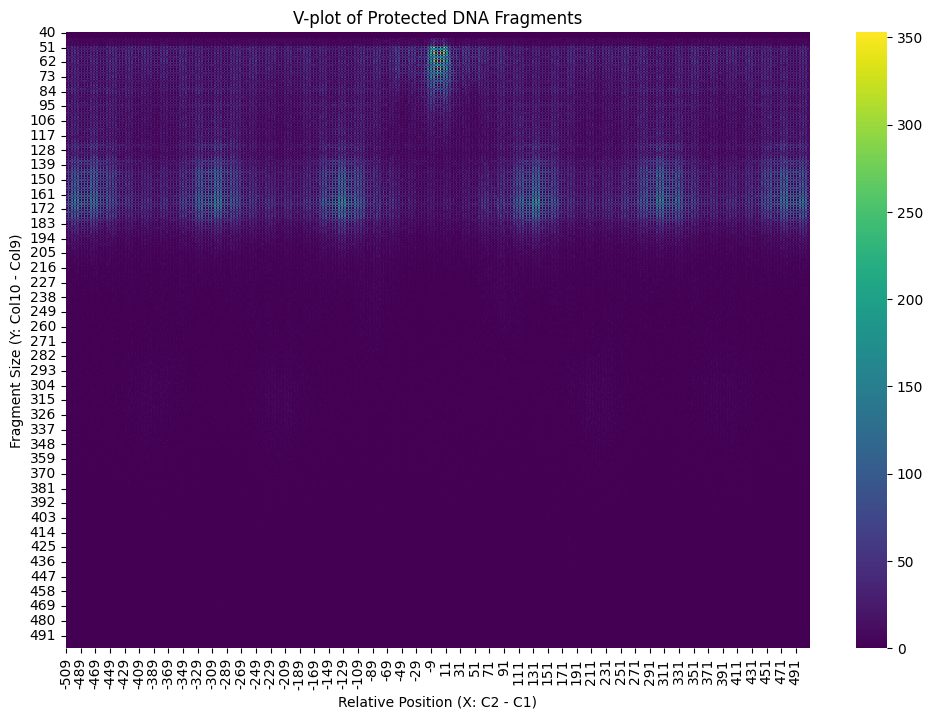

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the file
df = pd.read_csv('mapped.bed.gz', sep='\t', header=None)

# Define centers
C1 = (df[2] + df[3]) / 2  # Columns 3 and 4 (zero-indexed 2 and 3)
C2 = (df[8] + df[9]) / 2  # Columns 9 and 10 (zero-indexed 8 and 9)

# Calculate X and Y
X = C2 - C1
Y = df[9] - df[8]  # Column10 - Column9

# Build a DataFrame with counts
data = pd.DataFrame({'X': X.round().astype(int), 'Y': Y.round().astype(int)})
heatmap_data = data.groupby(['X', 'Y']).size().reset_index(name='Z')

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot_table(index='Y', columns='X', values='Z', fill_value=0)

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot, cmap='viridis')
plt.title('V-plot of Protected DNA Fragments')
plt.xlabel('Relative Position (X: C2 - C1)')
plt.ylabel('Fragment Size (Y: Col10 - Col9)')
plt.show()
